# 05 - Hyperparameter Optimization

The true CATE $\tau(X)$ is never observed, so there is no direct validation MSE to tune against. The HPO objective is a surrogate: the doubly robust pseudo-outcome MSE (DR-loss),

$$
\widetilde Y_i^{DR} \;=\; \hat m_1(X_i) - \hat m_0(X_i)
   + \frac{T_i (Y_i - \hat m_1(X_i))}{\hat e(X_i)}
   - \frac{(1 - T_i)(Y_i - \hat m_0(X_i))}{1 - \hat e(X_i)}.
$$

$L_{DR}(\hat\tau) = \mathbb{E}[(\widetilde Y^{DR} - \hat\tau(X))^2]$, unbiased for the tau-risk up to an additive constant when either nuisance model is consistent.

Protocol: pseudo-outcomes built once with 5-fold cross-fitted nuisances and reused across trials; Optuna TPE, 50 trials, each scored by 3-fold CV DR-loss inside the training set; final selection by Qini on the untouched 20% hold-out. On a single split, DR-loss winners are not guaranteed to be Qini winners, hence the final Qini check.

## Setup

In [1]:
ARTIFACT_NAME = '05_hpo'
import time, warnings, pickle, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from criteo_data import fetch_criteo
from sklift.metrics import uplift_auc_score, qini_auc_score, uplift_at_k

warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'  # loky workers (n_jobs=-1) read this at startup
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

SEED = 42
np.random.seed(SEED)
SAMPLE_SIZE = 500_000

print('Loading Criteo...')
ds = fetch_criteo(target_col='conversion')
X_full, y_full, treat_full = ds.data, ds.target, ds.treatment
if SAMPLE_SIZE and SAMPLE_SIZE < len(X_full):
    idx = np.random.choice(len(X_full), SAMPLE_SIZE, replace=False)
    X_full = X_full.iloc[idx].reset_index(drop=True)
    y_full = y_full.iloc[idx].reset_index(drop=True)
    treat_full = treat_full.iloc[idx].reset_index(drop=True)

strat = treat_full.values * 2 + y_full.values
X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
    X_full.values, y_full.values, treat_full.values,
    test_size=0.2, random_state=SEED, stratify=strat,
)
print(f'Train: {len(X_train):,}  Test: {len(X_test):,}')

results = {}
qini_curves = {}

def evaluate(name, scores, elapsed):
    s = np.asarray(scores).flatten()
    row = {
        'AUUC':       round(uplift_auc_score(y_test, s, t_test), 6),
        'Qini':       round(qini_auc_score(y_test, s, t_test),   6),
        'Uplift@10%': round(uplift_at_k(y_test, s, t_test, strategy='by_group', k=0.1), 4),
        'Uplift@20%': round(uplift_at_k(y_test, s, t_test, strategy='by_group', k=0.2), 4),
        'Time(s)':    round(elapsed, 1),
    }
    results[name] = row
    qini_curves[name] = s
    print(f'[{name:<28}]  Qini={row["Qini"]:.6f}  @10%={row["Uplift@10%"]:.4f}  @20%={row["Uplift@20%"]:.4f}  time={row["Time(s)"]}s')
    return row


Loading Criteo...


Train: 400,000  Test: 100,000


## 1. DR pseudo-outcomes (built once)

Nuisances $\hat e, \hat m_0, \hat m_1$ are 5-fold cross-fitted: each fold is predicted by models trained on the other folds, so residuals reflect generalization error. In-sample nuisances would bias the pseudo-outcome toward zero and push HPO to underfit. $\hat e$ is clipped to [0.01, 0.99] to cap IPW variance.

In [2]:
from sklearn.model_selection import StratifiedKFold
from lightgbm import LGBMClassifier, LGBMRegressor

def crossfit_dr_pseudo(X, T, Y, n_splits=5, clip=(0.01, 0.99), seed=SEED):
    n = len(X)
    y0 = np.zeros(n); y1 = np.zeros(n); e = np.zeros(n)
    # Stratify folds on (treatment x outcome): conversions are ~0.3% and the
    # control arm is only ~15%, so plain KFold can leave a fold with too few
    # treated/control positives to fit m0/m1 stably.
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    strat = T * 2 + Y
    for fold, (tr, te) in enumerate(skf.split(X, strat)):
        params = dict(n_estimators=300, learning_rate=0.05, max_depth=6, num_leaves=63,
                      min_child_samples=50, random_state=seed, n_jobs=-1, verbose=-1)
        prop = LGBMClassifier(**params).fit(X[tr], T[tr])
        e[te] = prop.predict_proba(X[te])[:, 1]
        m0 = LGBMClassifier(**params).fit(X[tr][T[tr]==0], Y[tr][T[tr]==0])
        m1 = LGBMClassifier(**params).fit(X[tr][T[tr]==1], Y[tr][T[tr]==1])
        y0[te] = m0.predict_proba(X[te])[:, 1]
        y1[te] = m1.predict_proba(X[te])[:, 1]
        print(f'fold {fold+1}/{n_splits} done')
    e = np.clip(e, *clip)
    pseudo = (y1 - y0) + T*(Y - y1)/e - (1-T)*(Y - y0)/(1 - e)
    return pseudo, y0, y1, e

t0 = time.time()
pseudo, y0_hat, y1_hat, e_hat = crossfit_dr_pseudo(X_train, t_train, y_train)
print(f'DR pseudo-outcomes built in {time.time()-t0:.1f}s')
print(f'pseudo: mean={pseudo.mean():.5f}  std={pseudo.std():.5f}')

fold 1/5 done


fold 2/5 done


fold 3/5 done


fold 4/5 done


fold 5/5 done
DR pseudo-outcomes built in 62.4s
pseudo: mean=0.00046  std=0.20822


Sanity check: the pseudo-outcome mean should be close to the difference-in-means ATE (~0.0008); the std is much larger than the mean because of the IPW terms. That variance is why DR-loss is a noisy proxy for the tau-risk in finite samples.

## 2. Optuna search

We tune an `LGBMRegressor` fit to $\widetilde Y^{DR}$; its prediction is $\hat\tau(x)$ (a DR-Learner with a tunable final stage). Objective: 3-fold cross-validated MSE on the pseudo-outcome, independent of the outer 5-fold cross-fitting. Sampler: Optuna TPE, 50 trials; no pruning, since each trial is an atomic `cross_val_score`.

In [3]:
import optuna
from sklearn.model_selection import cross_val_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

def dr_objective(trial):
    params = dict(
        n_estimators       = trial.suggest_int('n_estimators', 100, 600, step=50),
        learning_rate      = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        max_depth          = trial.suggest_int('max_depth', 3, 10),
        num_leaves         = trial.suggest_int('num_leaves', 15, 127),
        min_child_samples  = trial.suggest_int('min_child_samples', 20, 200),
        colsample_bytree   = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_alpha          = trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        reg_lambda         = trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        random_state=SEED, n_jobs=-1, verbose=-1,
    )
    # Note: we do NOT tune `subsample` - LightGBM row-bagging is inert unless
    # `subsample_freq >= 1`, so it would be a dead search dimension.
    model = LGBMRegressor(**params)
    scores = cross_val_score(model, X_train, pseudo, cv=3,
                             scoring='neg_mean_squared_error', n_jobs=-1)
    return -scores.mean()  # lower is better

study = optuna.create_study(direction='minimize',
                            sampler=optuna.samplers.TPESampler(seed=SEED))
t0 = time.time()
study.optimize(dr_objective, n_trials=50, show_progress_bar=False)
print(f'\nOptuna best DR-loss: {study.best_value:.6f}  (time: {time.time()-t0:.1f}s)')
print('Best params:'); print(study.best_params)


Optuna best DR-loss: 0.043263  (time: 191.6s)
Best params:
{'n_estimators': 100, 'learning_rate': 0.012143411110419673, 'max_depth': 7, 'num_leaves': 32, 'min_child_samples': 152, 'colsample_bytree': 0.8607988021638561, 'reg_alpha': 0.009879152102367393, 'reg_lambda': 0.0012482494536406406}


## 3. Baseline vs tuned on Qini

Both configs are retrained on the full training set and scored by Qini on the 20% hold-out. If the tuned model wins on DR-loss but loses on Qini, that is the surrogate-vs-true-risk mismatch: Schuler et al. 2018 document that DR-loss is a generally good but imperfect selection criterion, especially with a small ATE and rare outcomes (Criteo's regime). Hence the two-stage protocol: screen by DR-loss, select by held-out Qini.

In [4]:
# Baseline: the untuned LightGBM config used elsewhere in the project (notebook 01).
# (subsample is omitted: it is inert without subsample_freq; colsample_bytree=0.8
#  is the one active regularizer that differs from LightGBM defaults.)
t0 = time.time()
baseline = LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                         num_leaves=63, min_child_samples=50, colsample_bytree=0.8,
                         random_state=SEED, n_jobs=-1, verbose=-1)
baseline.fit(X_train, pseudo)
evaluate('DR-LGBM baseline', baseline.predict(X_test), time.time()-t0)

# Tuned
t0 = time.time()
tuned = LGBMRegressor(**study.best_params, random_state=SEED, n_jobs=-1, verbose=-1)
tuned.fit(X_train, pseudo)
evaluate('DR-LGBM tuned', tuned.predict(X_test), time.time()-t0)

[DR-LGBM baseline            ]  Qini=0.158615  @10%=0.0104  @20%=0.0057  time=3.2s


[DR-LGBM tuned               ]  Qini=0.069162  @10%=0.0096  @20%=0.0039  time=1.4s


{'AUUC': 0.002313,
 'Qini': 0.069162,
 'Uplift@10%': 0.0096,
 'Uplift@20%': 0.0039,
 'Time(s)': 1.4}

## 4. Search visualization

Left: DR-loss per trial with the running best. Right: hyperparameter importance from Optuna's fANOVA-style decomposition.

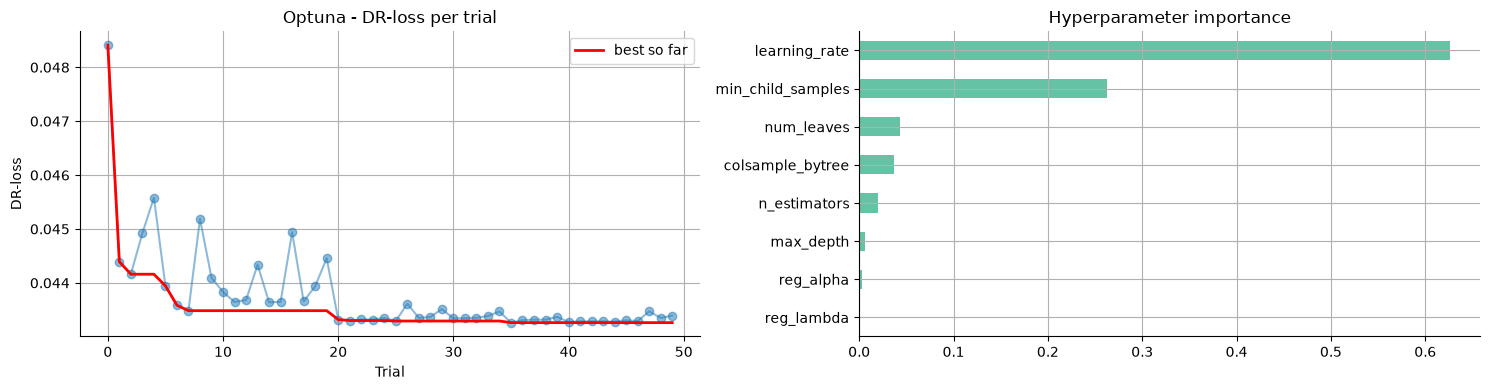

In [5]:
hist = study.trials_dataframe()
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot(hist['number'], hist['value'], 'o-', alpha=0.5)
axes[0].plot(hist['number'], hist['value'].cummin(), 'r-', lw=2, label='best so far')
axes[0].set_title('Optuna - DR-loss per trial')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('DR-loss'); axes[0].legend()

importances = optuna.importance.get_param_importances(study)
pd.Series(importances).sort_values().plot.barh(ax=axes[1], color='#66c2a5')
axes[1].set_title('Hyperparameter importance')

plt.tight_layout(); plt.savefig('hpo_optuna.png', dpi=140); plt.show()

## Results

In [6]:
df = pd.DataFrame(results).T.astype(float).sort_values('Qini', ascending=False)
print('\n=== Leaderboard ===')
print(df.to_string(float_format=lambda x: f'{x:.6f}' if abs(x) < 10 else f'{x:.1f}'))
df.style.background_gradient(subset=['AUUC','Qini','Uplift@10%','Uplift@20%'], cmap='Greens') \
        .background_gradient(subset=['Time(s)'], cmap='Reds_r') \
        .format({'AUUC':'{:.6f}','Qini':'{:.6f}','Uplift@10%':'{:.4f}','Uplift@20%':'{:.4f}','Time(s)':'{:.1f}'})



=== Leaderboard ===
                     AUUC     Qini  Uplift@10%  Uplift@20%  Time(s)
DR-LGBM baseline 0.005337 0.158615    0.010400    0.005700 3.200000
DR-LGBM tuned    0.002313 0.069162    0.009600    0.003900 1.400000


,AUUC,Qini,Uplift@10%,Uplift@20%,Time(s)
DR-LGBM baseline,0.005337,0.158615,0.0104,0.0057,3.2
DR-LGBM tuned,0.002313,0.069162,0.0096,0.0039,1.4


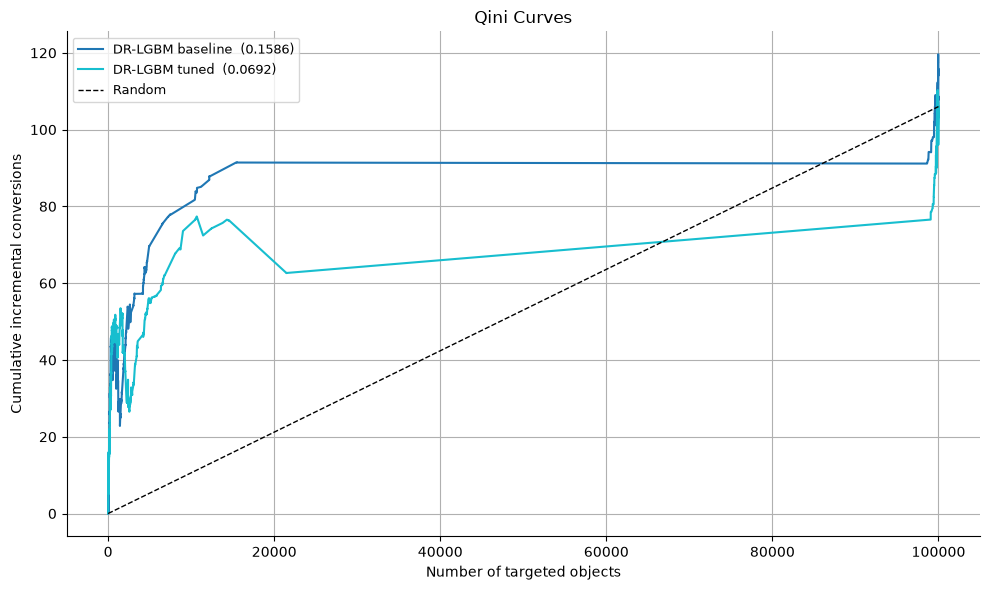

In [7]:
# Qini curves drawn by hand (see notebook 02): calling plot_qini_curve on a
# shared axis crashes on matplotlib >= 3.7.
from sklift.metrics import qini_curve
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(qini_curves)))
end = None
for (name, s), c in zip(qini_curves.items(), colors):
    x, y = qini_curve(y_test, np.asarray(s).flatten(), t_test)
    ax.plot(x, y, label=f'{name}  ({results[name]["Qini"]:.4f})', color=c)
    end = (x[-1], y[-1])
if end is not None:
    ax.plot([0, end[0]], [0, end[1]], 'k--', lw=1, label='Random')
ax.set_xlabel('Number of targeted objects')
ax.set_ylabel('Cumulative incremental conversions')
ax.set_title('Qini Curves')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.savefig(f'{ARTIFACT_NAME}_qini.png', dpi=140, bbox_inches='tight'); plt.show()

In [8]:
# Save tuned hyperparameters for the benchmark notebook
os.makedirs('artifacts', exist_ok=True)
with open('artifacts/05_hpo_best_params.pkl', 'wb') as f:
    pickle.dump({'best_params': study.best_params, 'best_value': study.best_value}, f)
print('Saved best params')

Saved best params


In [9]:
# Persist results for the final benchmark notebook
os.makedirs('artifacts', exist_ok=True)
with open(f'artifacts/{ARTIFACT_NAME}.pkl', 'wb') as f:
    pickle.dump({'results': results, 'qini_curves': qini_curves,
                 'y_test': y_test, 't_test': t_test}, f)
print(f"Saved artifacts/{ARTIFACT_NAME}.pkl")


Saved artifacts/05_hpo.pkl


## Summary

HPO for CATE needs a surrogate objective (DR-loss), cross-fitted nuisances, and final selection by Qini on a fresh hold-out. Tuning a DR-Learner via DR-loss is the matched case; for other estimators the surrogate is still valid but less aligned, and method-specific tuners (`CausalForest.tune()`, `CausalForestDML.tune()`) may do better.

Next: [06_benchmark.ipynb](06_benchmark.ipynb) - the cross-method leaderboard with bootstrap CIs.